# 03 — RGC Cluster Characterization

Load CNN embedding cluster assignments, compare KMeans vs hierarchical clusters, and export cluster review sheets for manual biological interpretation.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import adjusted_rand_score

plt.style.use("default")

In [2]:
data_dir = Path("../data/cropped")
output_dir = Path("../outputs/rgc_image_analysis")
fig_dir = output_dir / "figures"

assignments_path = output_dir / "rgc_cluster_assignments.csv"
assignments = pd.read_csv(assignments_path)

display(assignments.head())

print("Images:", len(assignments))

,image_index,filename,kmeans_cluster,hierarchical_cluster
0,0,cropped0.tif,2,1
1,1,cropped1.tif,1,3
2,2,cropped10.tif,1,3
3,3,cropped11.tif,2,1
4,4,cropped12.tif,2,1


Images: 45


In [3]:
kmeans_counts = assignments["kmeans_cluster"].value_counts().sort_index()
hier_counts = assignments["hierarchical_cluster"].value_counts().sort_index()

cluster_counts = pd.DataFrame({
    "kmeans_count": kmeans_counts,
    "hierarchical_count": hier_counts
}).fillna(0).astype(int)

display(cluster_counts)

cluster_counts.to_csv(output_dir / "rgc_cluster_counts.csv")

,kmeans_count,hierarchical_count
1,6,32
2,33,5
3,5,7
4,1,1


In [4]:
cross_tab = pd.crosstab(
    assignments["kmeans_cluster"],
    assignments["hierarchical_cluster"]
)

display(cross_tab)

cross_tab.to_csv(output_dir / "rgc_kmeans_vs_hierarchical_crosstab.csv")

ari = adjusted_rand_score(
    assignments["kmeans_cluster"],
    assignments["hierarchical_cluster"]
)

print("Adjusted Rand Index:", ari)

hierarchical_cluster,1,2,3,4
kmeans_cluster,,,,
1,0,0,6,0
2,32,0,1,0
3,0,5,0,0
4,0,0,0,1


Adjusted Rand Index: 0.9226463899592464


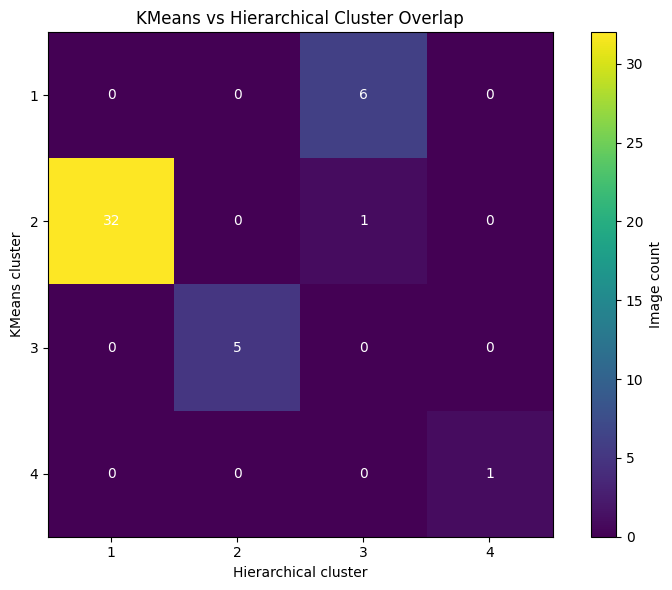

Saved:
../outputs/rgc_image_analysis/figures/rgc_kmeans_vs_hierarchical_overlap.tiff


In [5]:
fig = plt.figure(figsize=(8, 6))

plt.imshow(cross_tab.values, cmap="viridis")

plt.xticks(ticks=np.arange(cross_tab.shape[1]), labels=cross_tab.columns)
plt.yticks(ticks=np.arange(cross_tab.shape[0]), labels=cross_tab.index)

plt.xlabel("Hierarchical cluster")
plt.ylabel("KMeans cluster")
plt.title("KMeans vs Hierarchical Cluster Overlap")

for i in range(cross_tab.shape[0]):
    for j in range(cross_tab.shape[1]):
        plt.text(j, i, cross_tab.values[i, j], ha="center", va="center", color="white")

plt.colorbar(label="Image count")
plt.tight_layout()

out_path = fig_dir / "rgc_kmeans_vs_hierarchical_overlap.tiff"
fig.savefig(out_path, dpi=300, format="tiff", bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:")
print(out_path)

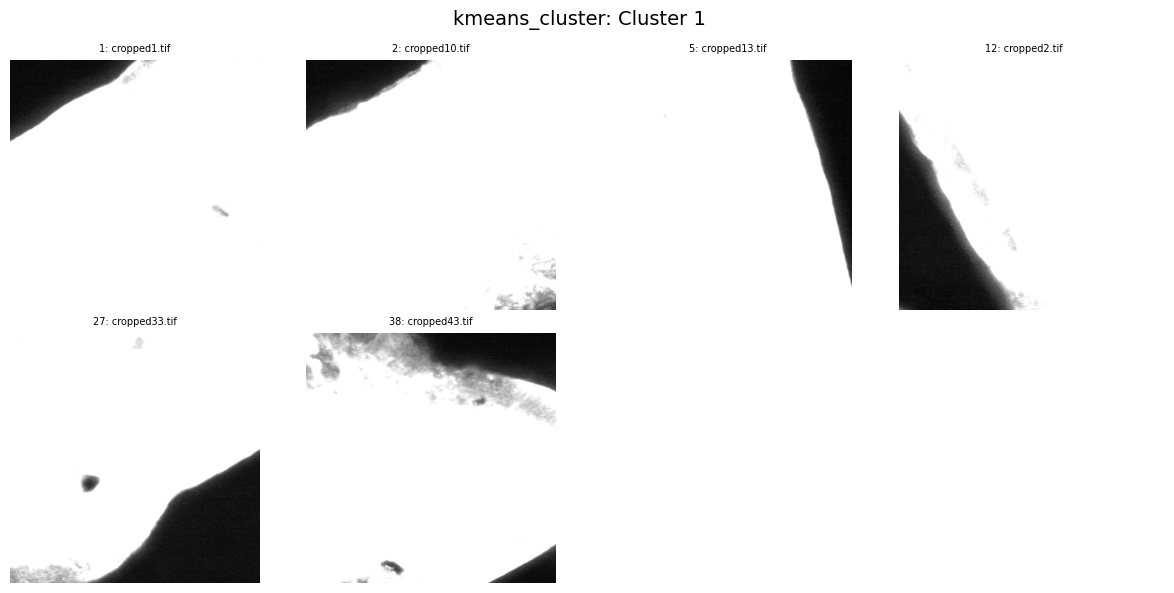

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_cluster_1_review.tiff


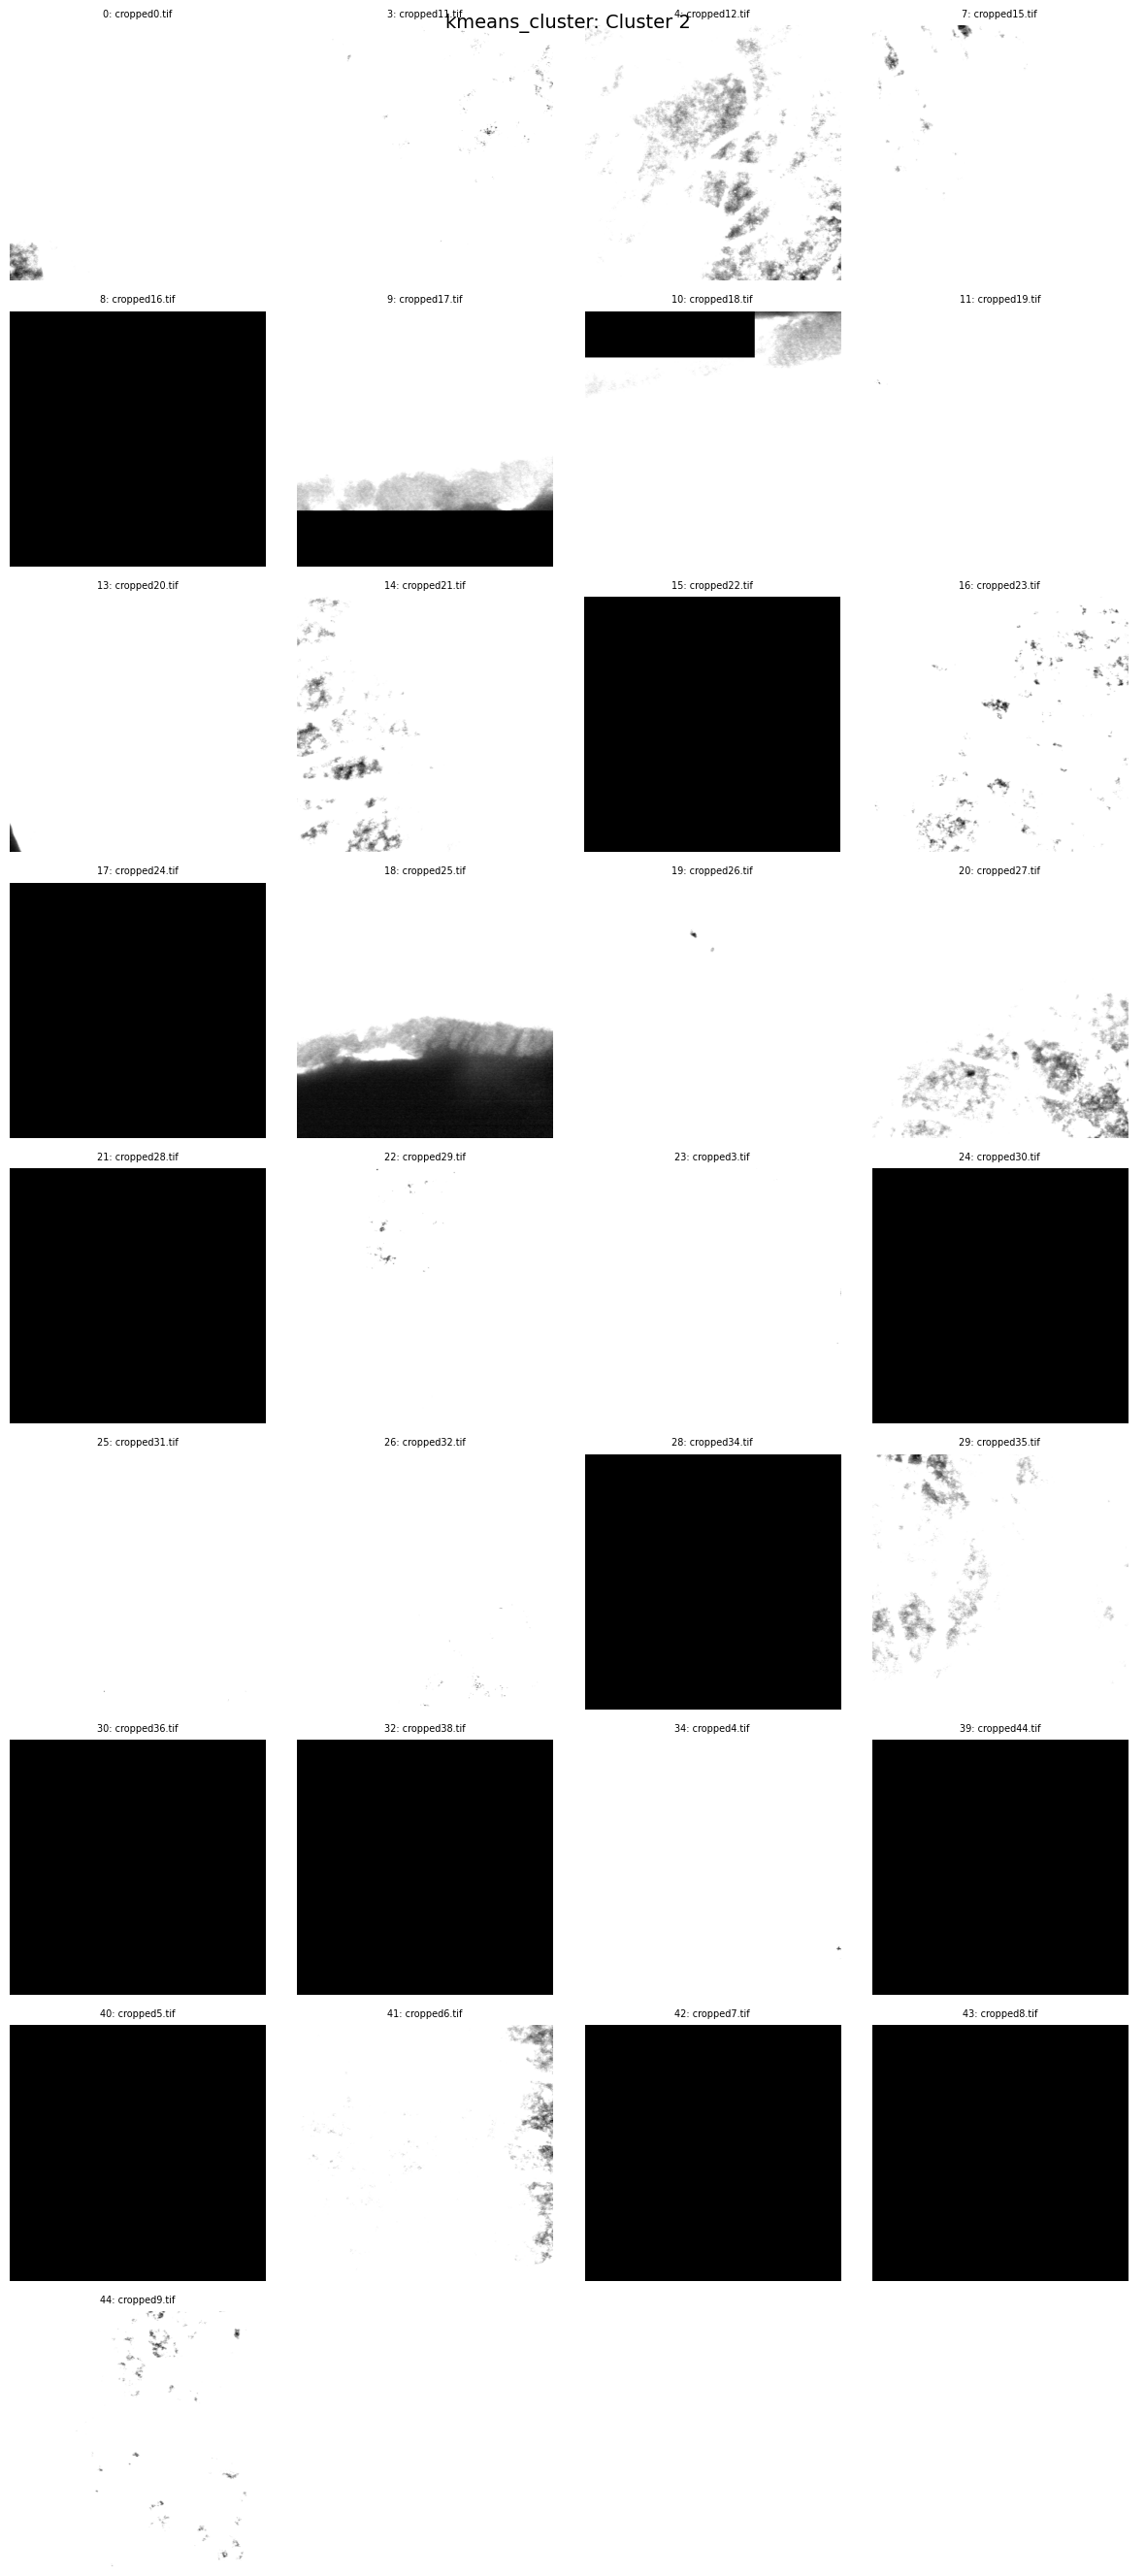

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_cluster_2_review.tiff


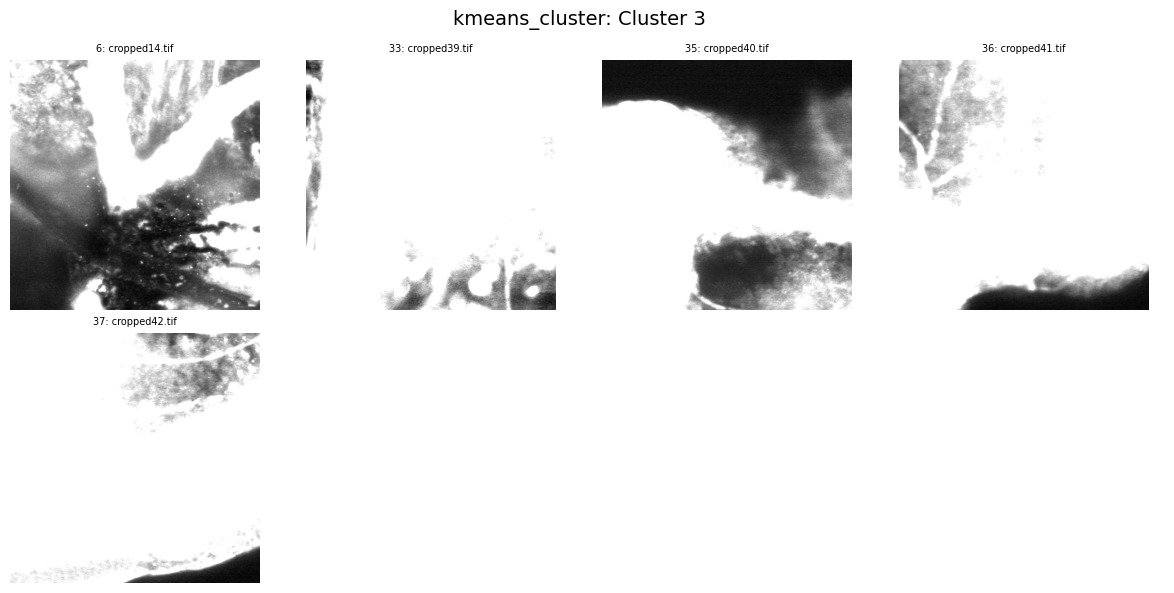

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_cluster_3_review.tiff


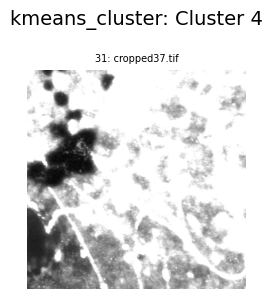

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_cluster_4_review.tiff


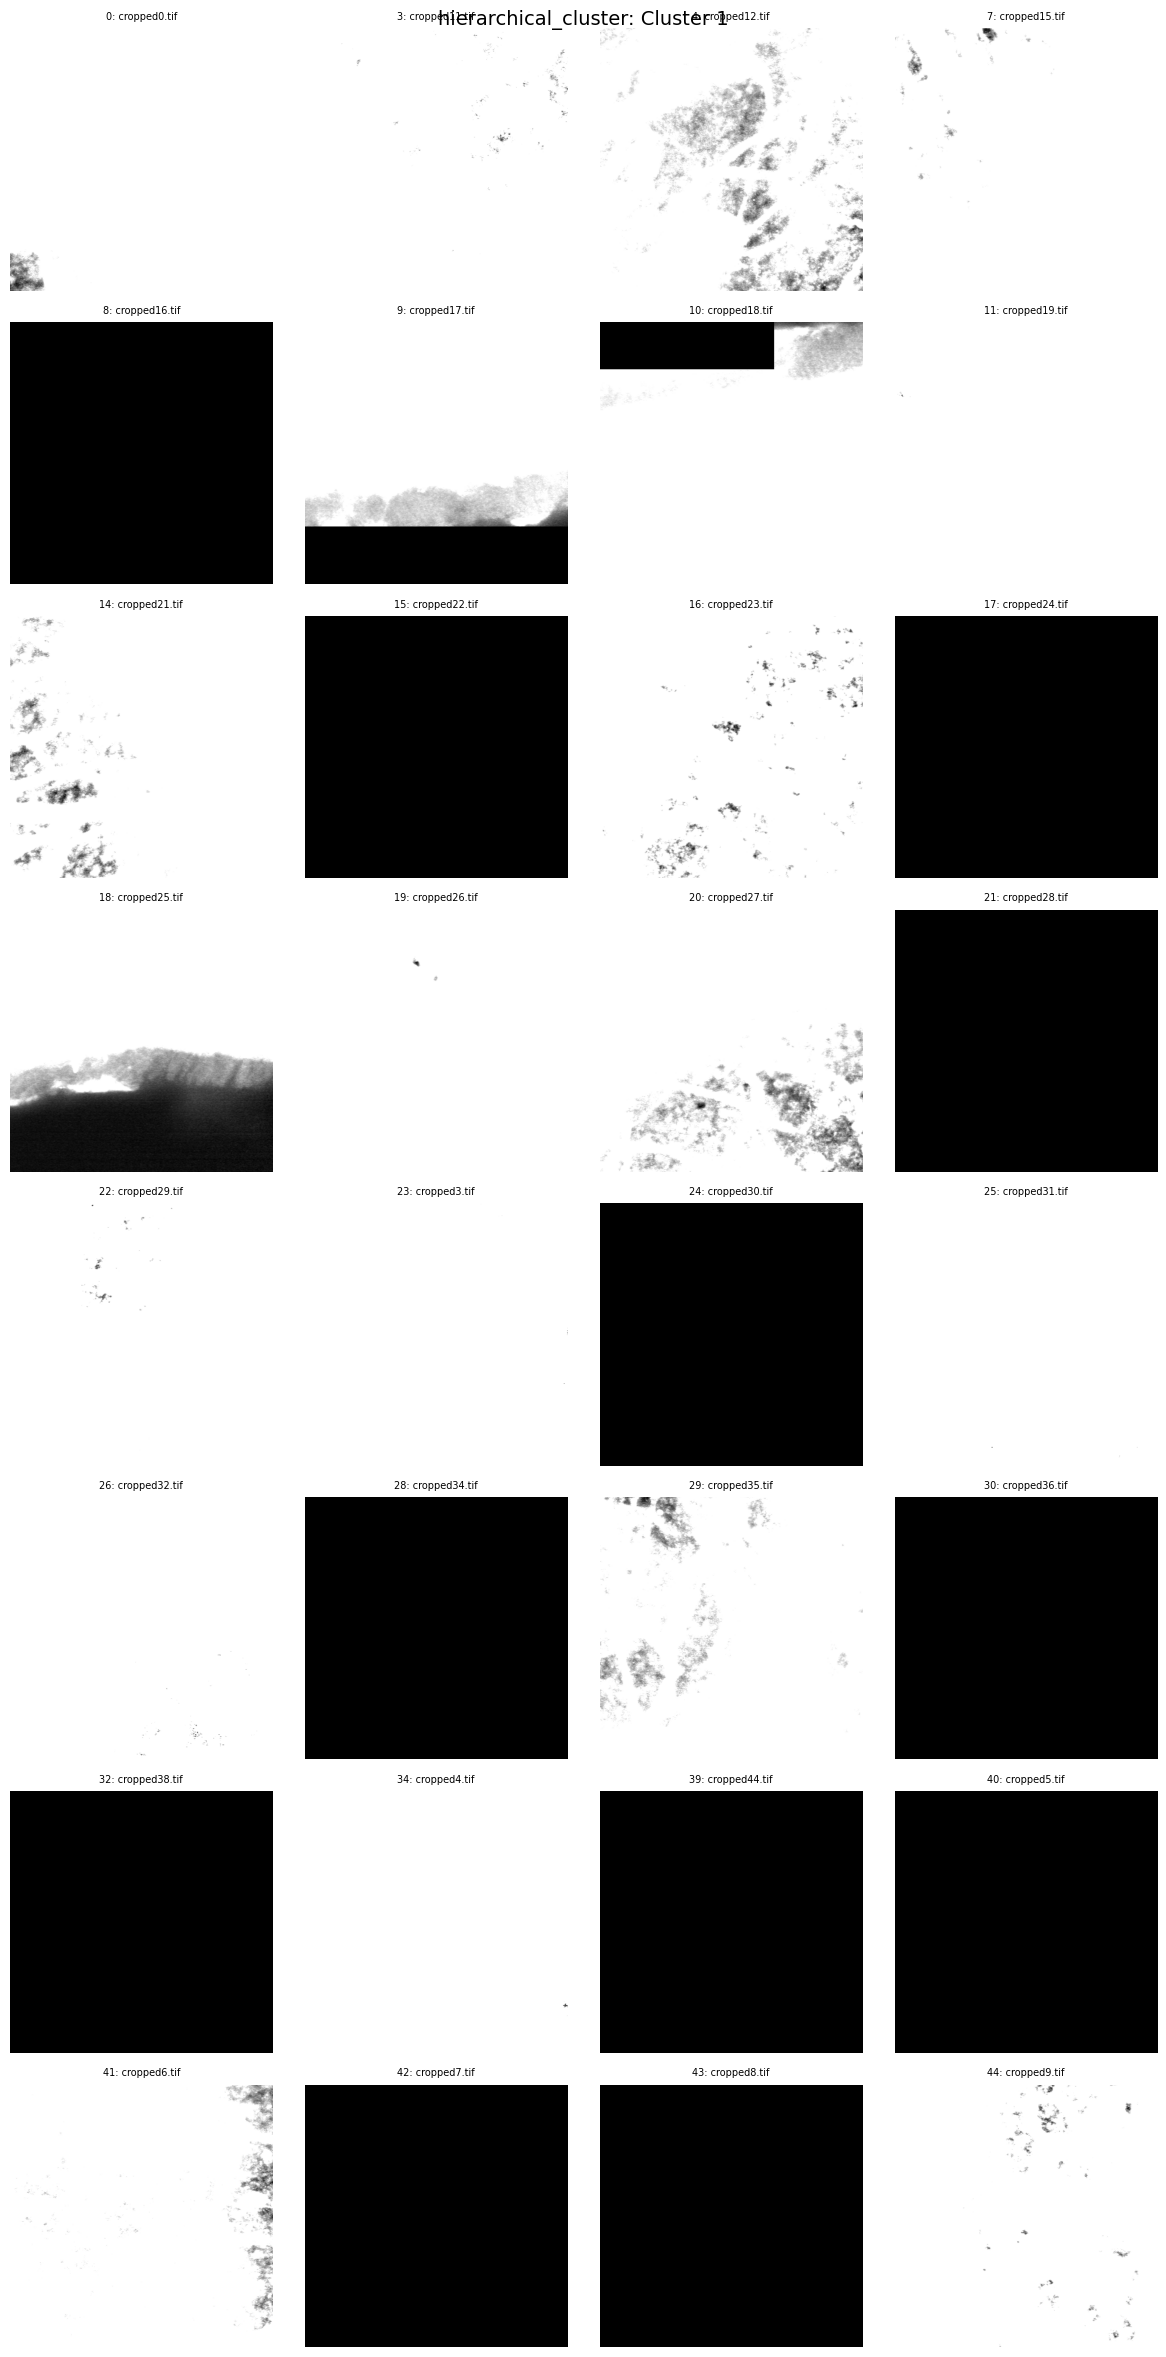

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_cluster_1_review.tiff


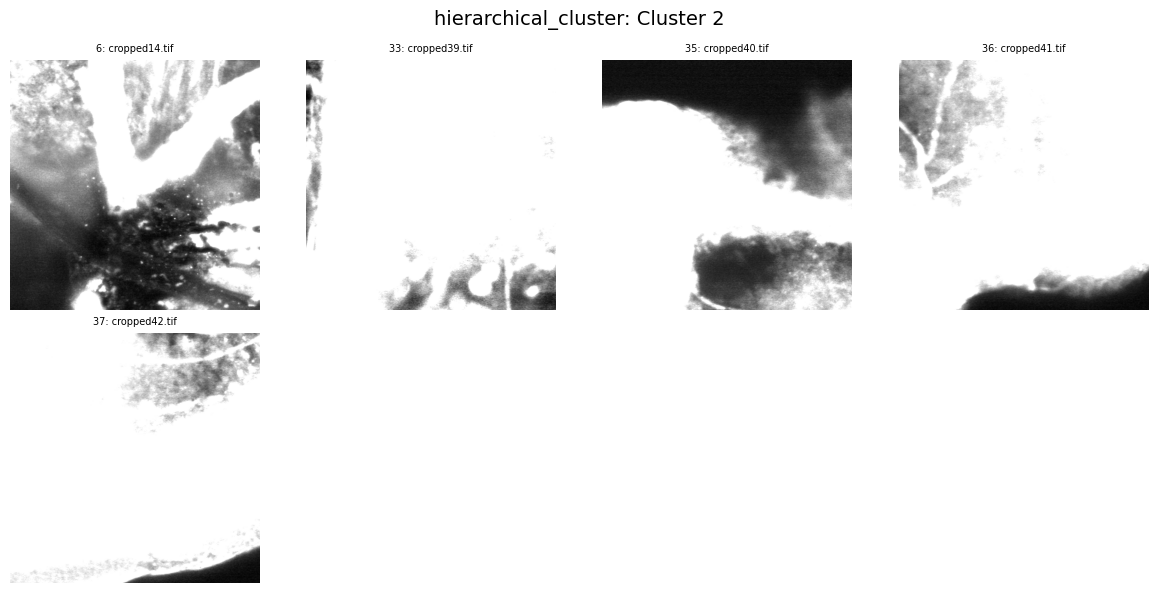

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_cluster_2_review.tiff


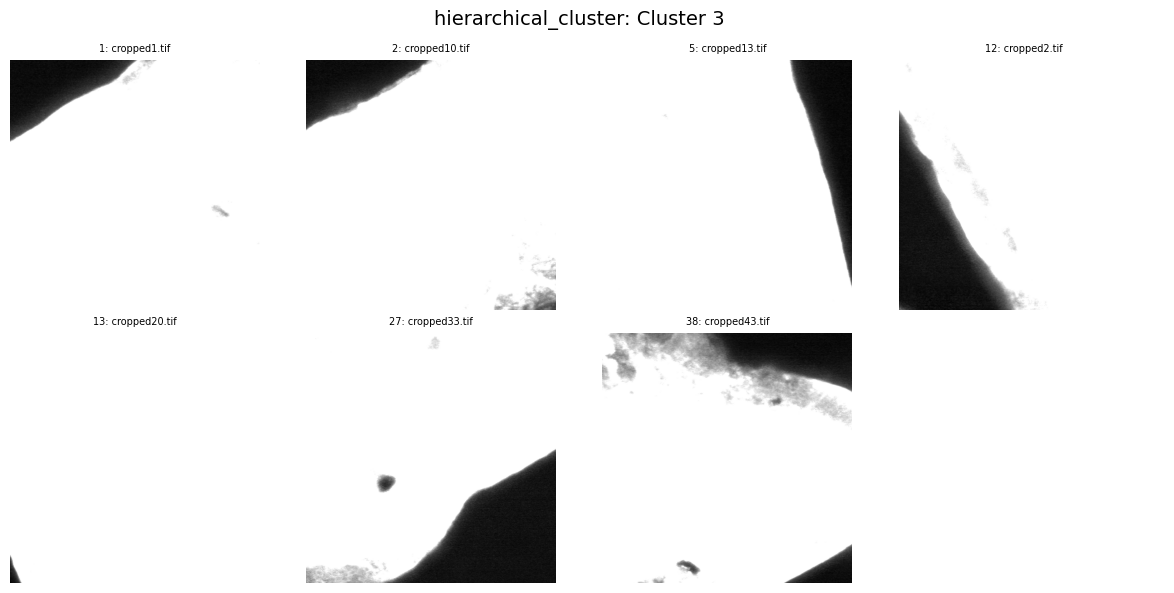

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_cluster_3_review.tiff


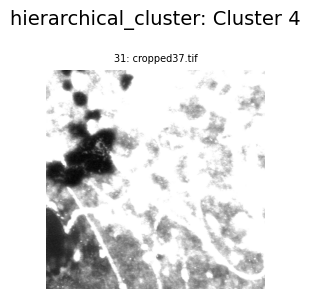

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_cluster_4_review.tiff


In [6]:
def save_cluster_sheets(method_col):
    for cluster in sorted(assignments[method_col].unique()):
        sub = assignments[assignments[method_col] == cluster]

        n = len(sub)
        n_cols = min(4, n)
        n_rows = int(np.ceil(n / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
        axes = np.array(axes).reshape(-1)

        for ax, (_, row) in zip(axes, sub.iterrows()):
            img = Image.open(data_dir / row["filename"]).convert("L")
            ax.imshow(img, cmap="gray")
            ax.set_title(f'{row["image_index"]}: {row["filename"]}', fontsize=7)
            ax.axis("off")

        for ax in axes[n:]:
            ax.axis("off")

        plt.suptitle(f"{method_col}: Cluster {cluster}", fontsize=14)
        plt.tight_layout()

        out_path = fig_dir / f"rgc_{method_col}_cluster_{cluster}_review.tiff"
        fig.savefig(out_path, dpi=300, format="tiff", bbox_inches="tight")
        plt.show()
        plt.close(fig)

        print("Saved:", out_path)

save_cluster_sheets("kmeans_cluster")
save_cluster_sheets("hierarchical_cluster")

Manual characterization suggestions:

For each cluster, record visible morphology features such as:
- dendritic field size
- soma visibility/size
- branching density
- radial symmetry
- elongation/asymmetry
- image quality/artifact level
- sparse vs dense arbor
- possible RGC subtype notes

Save those observations into a new table later, then compare them to the unsupervised cluster assignments.